In [ ]:
from __future__ import annotations
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.base import BaseEstimator
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, KFold, cross_val_score

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("preprocessed_data/data.csv")
SIMPLE = True
LOG_TRANSFORMED_RUNTIME = "log_runtime" in df.columns

In [ ]:
def proportional_errors(
        truth:np.ndarray,
        predictions:np.ndarray,
        runtime_log_transformed:bool = LOG_TRANSFORMED_RUNTIME) -> np.ndarray:
    """Proportional error of a model given the predicted runtimes and true runtimes"""
    if runtime_log_transformed:
        truth = np.exp(truth)
        predictions = np.exp(predictions)
    errors = np.abs(truth - predictions) / truth
    return errors

def mean_proportional_error(
        y_true:np.ndarray, y_pred:np.ndarray, 
        log_transformed_runtime:bool = LOG_TRANSFORMED_RUNTIME) -> float:
    """mean proportional error of log transformed runtime and """
    if log_transformed_runtime:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) / y_true))

# add mean proportional error to sklearn's scoring system
prop_error_scorer = make_scorer(mean_proportional_error, greater_is_better=False)

def drop_other_t_cols(df, curr_t:int, simple:bool=SIMPLE):
    """
    Given the dataframe and current time (0 through 4) drop other time cols from the dataframe.
    Parameters:
        df: the dataframe to drop columns from
        curr_t: current time (0 through 4) for training/testing
        simple: whether or not models are simple (contain fewer cols). 
         - if simple is True: drops every performance col that isn't f"..._t{current_t}"
         - if simple is False: only drops future performance cols (>curr_t)
    returns:
        df: updated dataframe with dropped columns
    """
    drop_cols = []
    for col in df.columns:
        if col[-3:-1] != "_t":
            continue
        col_t = int(col[-1])
        if simple:
            if col_t != curr_t:
                drop_cols.append(col)
        elif col_t > curr_t:
            drop_cols.append(col)
    return df.drop(columns=drop_cols)


def split_df_by_times(
        df:pd.DataFrame,
        simple:bool = SIMPLE,
        log_transformed_runtime:bool = LOG_TRANSFORMED_RUNTIME
    ) -> dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]]:
    """
    Get dataframe subsets of runs that are longer than time t_i
    Returns:
        dfs: dictionary of {f"t{i}":train_test_split(dataframe)} 
            - e.g. {"t2":(train_X, test_X, train_y, test_y)}
    """
    runtime_col = "log_runtime" if log_transformed_runtime else "runtime"
    dfs = {}
    for t in range(5):
        subset_df = df[df["time_sample"] >= t]  # get runs that are at least as long as t
        subset_df = drop_other_t_cols(df=subset_df, curr_t=t, simple=simple)
        X = subset_df.drop(columns=[runtime_col, "time_sample"])
        y = subset_df[runtime_col]
        dfs[f"t{t}"] = train_test_split(X, y, test_size=0.2)
    return dfs



def get_results_df(predictions_df: pd.DataFrame, log_transformed_runtime:bool=True) -> pd.DataFrame:
    """
    Aggregate metrics from predictions_df.
    Returns results_df with columns:
    model_name, time_sample, train_prop_err_mean, train_prop_err_med, train_mse,
    test_prop_err_mean, test_prop_err_med, test_mse
    """

    rows = []

    for (model_name, time_sample), df in predictions_df.groupby(["model_name", "time_sample"]):
        if log_transformed_runtime:
            df["runtime"] = df["log_runtime"].apply(np.exp)
            df["prediction"] = df["prediction"].apply(np.exp)
        train_df = df[df["dataset"] == "train"]
        test_df = df[df["dataset"] == "test"]

        rows.append({
            "model_name": model_name,
            "time_sample": time_sample,
            "train_prop_err_mean": train_df["prop_error"].mean(),
            "train_prop_err_med": train_df["prop_error"].median(),
            "train_rmse": np.sqrt(mean_squared_error(train_df["runtime"], train_df["prediction"])),
            "test_prop_err_mean": test_df["prop_error"].mean(),
            "test_prop_err_med": test_df["prop_error"].median(),
            "test_rmse": np.sqrt(mean_squared_error(test_df["runtime"], test_df["prediction"])),
        })
    results_df = pd.DataFrame(rows)
    return results_df

def train_and_test_models(
    models: dict[str, BaseEstimator],
    split_dfs: dict[str, tuple],
    log_transformed_runtime:bool = True
) -> pd.DataFrame:
    """
    Train all models on all time splits and return per-sample results.
    Returns predictions_df with columns:
        model_name, time_sample, runtime, prediction, prop_error, dataset (train/test)
    """

    rows = []
    runtime_col = "log_runtime" if log_transformed_runtime else "runtime"
    for model_name, model in models.items():
        for t, (train_X, test_X, train_y, test_y) in split_dfs.items():
            model.fit(train_X, train_y)
            # train dataset
            train_preds = model.predict(train_X)
            train_err = proportional_errors(train_y, train_preds)
            rows.append(pd.DataFrame({
                "model_name": model_name,
                "time_sample": t,
                runtime_col: train_y,
                "prediction": train_preds,
                "prop_error": train_err,
                "dataset": "train"
            }))
            # test dataset
            test_preds = model.predict(test_X)
            test_err = proportional_errors(test_y, test_preds)
            rows.append(pd.DataFrame({
                "model_name": model_name,
                "time_sample": t,
                runtime_col: test_y,
                "prediction": test_preds,
                "prop_error": test_err,
                "dataset": "test"
            }))
    predictions_df = pd.concat(rows, ignore_index=True)
    return predictions_df

In [4]:
dfs_split = split_df_by_times(df, simple=SIMPLE)

In [5]:
models = {
    "Linear Regression":LinearRegression(), 
    "Elastic Net":ElasticNet(),
    "Decision Tree":DecisionTreeRegressor(), 
    "Gradient Boosting":GradientBoostingRegressor(),
    "Random Forest": RandomForestRegressor(),
}

In [6]:
predictions_df = train_and_test_models(models, dfs_split)
results_df = get_results_df(predictions_df)

# Results 

## Plotting Functions

In [7]:
def lineplots_models_errors_by_time(results_df):
    """Creates lineplots comparing error metrics of all models by time sample"""
    metrics = [
        ("prop_err_med", "Median Proportional Error"),
        ("prop_err_mean", "Mean Proportional Error"),
        ("rmse", "RMSE"),
    ]

    datasets = ["train", "test"]
    fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
    for row, (metric_key, metric_label) in enumerate(metrics):
        for col, dataset in enumerate(datasets):
            ax = axes[row, col]
            y_col = f"{dataset}_{metric_key}"
            sns.lineplot(
                data=results_df,
                x="time_sample",
                y=y_col,
                hue="model_name",
                marker="o",
                ax=ax,
            )
            ax.set_xlabel("Time Sample")
            ax.set_ylabel(metric_label)
            ax.set_title(f"{metric_label} ({dataset})")

            if col != 1:  # avoid repeated legends
                ax.get_legend().remove()

    # single legend
    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

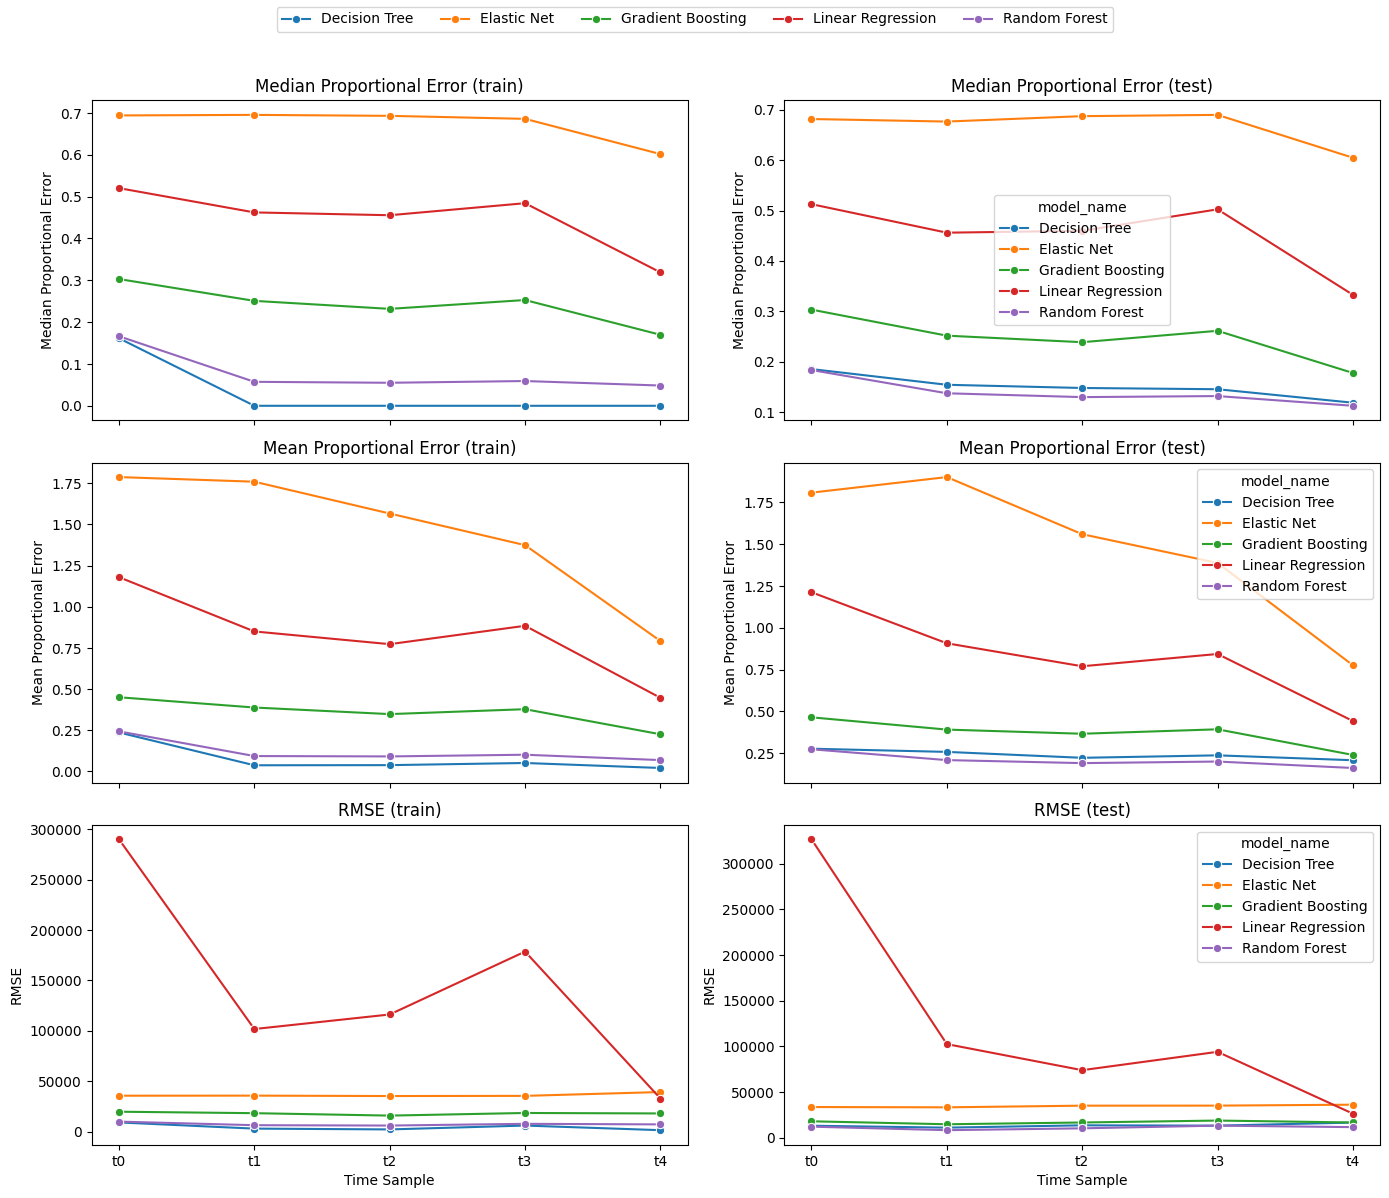

In [8]:
# plot results
lineplots_models_errors_by_time(results_df)

Notice the RMSE results begin to go down as time increases but then climb again as the time continues to increase. This is not surprising, as the datasets that these are being evaluated on change as well. At time t4, it only contains runs where runtime is at least an hour. That way, we are not predicting runtimes of runs that have already finished. Therefore, it would make sense that the RMSE of long runtimes is greater than the MSE of medium to long runtimes. This is part of the reason for introducing the proportional error metrics rather than solely relying on RMSE. By looking at those graphs, we can see that the proportional error of the non-linear models is going down as is expected.

In general for the proportional error metrics, there is an apparent pattern of linear models learning more as time goes on, however this is likely not the case. Because the time samples remove all past runs that are not as long as the current time sample, these linear models are simply able to generalize better to predict long runs than they are to predict a variety of short to long runs. 

To eliminate the confusion, we can run the same experiment on only the runs that lasted longer than t4 (1 hour). This way, we can see how the accuracy of each model changes over time without any compounding effects.

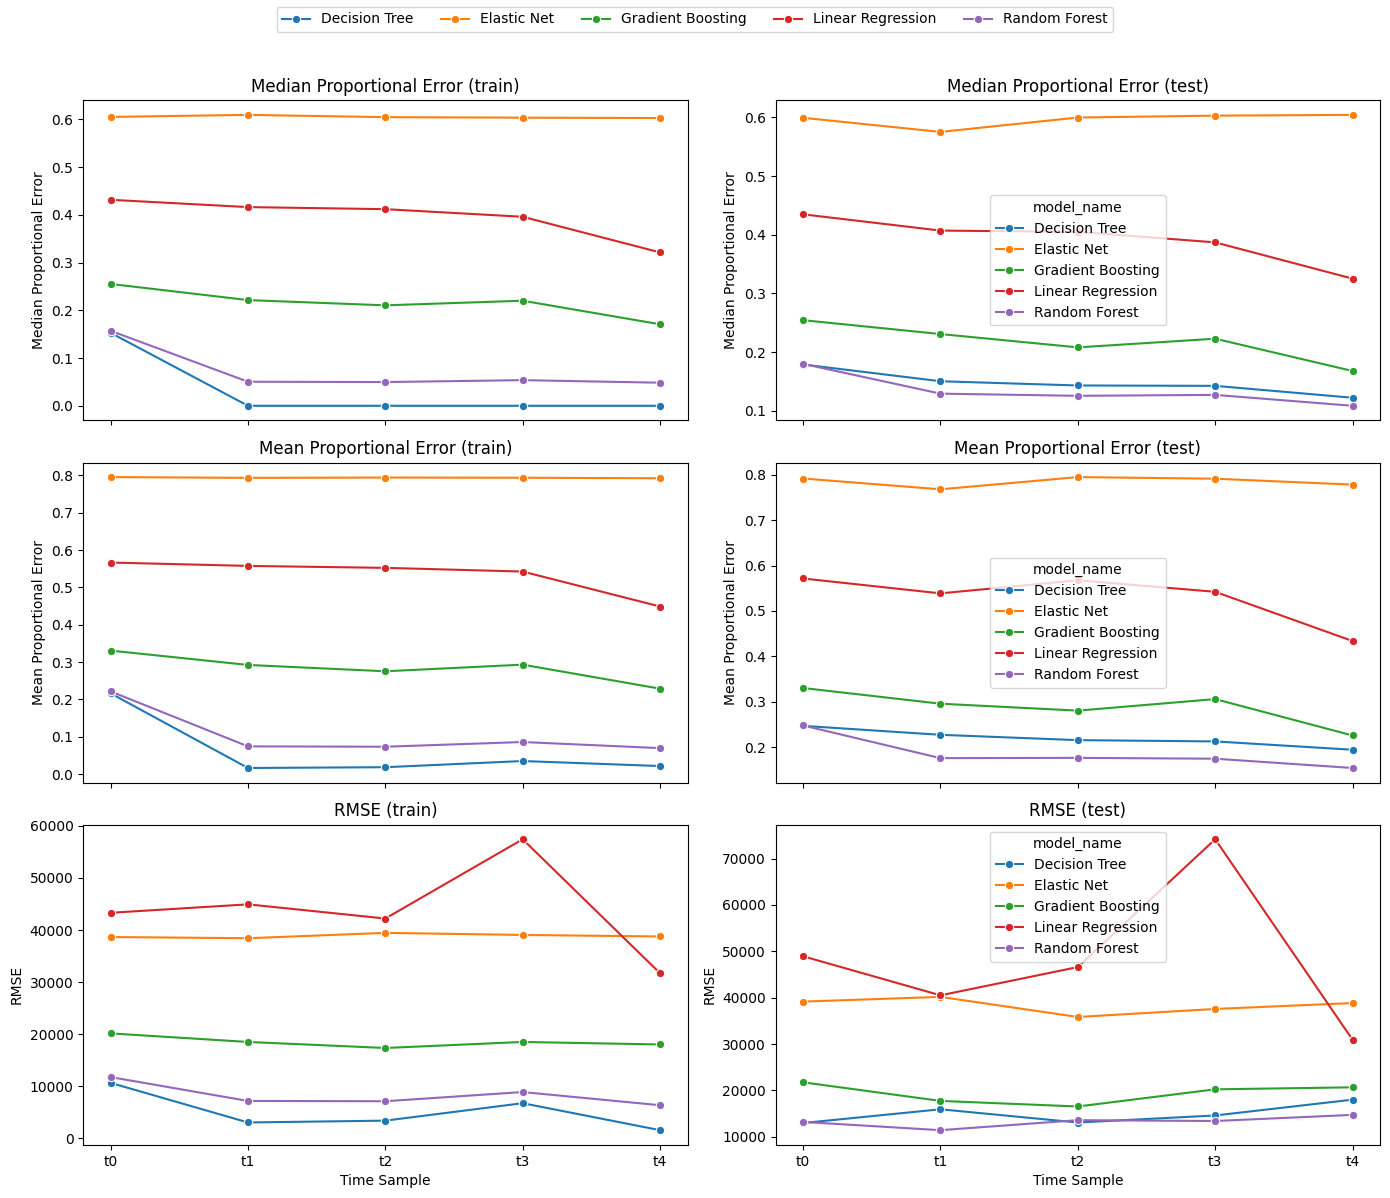

In [9]:
hour = 60*60
df_subset = None
if "log_runtime" in df.columns:
    df_subset = df[df["log_runtime"] > np.log(hour)]
else:
    df_subset = df[df["runtime"] > hour]
df_subset_split = split_df_by_times(df_subset, simple=SIMPLE)
predictions_subset_df = train_and_test_models(models, df_subset_split)
results_subset_df = get_results_df(predictions_subset_df)
lineplots_models_errors_by_time(results_subset_df)

In [10]:
def scatter_prop_errors_vs_runtimes(predictions_df: pd.DataFrame, dataset: str = "test"):
    """
    Create subplots of prop_error vs runtime scatterplots with rows = models, columns = time samples
    """

    df = predictions_df[predictions_df["dataset"] == dataset]
    models = df["model_name"].unique()
    times = df["time_sample"].unique()
    n_models = len(models)
    n_times = len(times)
    fig, axes = plt.subplots(
        n_models,
        n_times,
        figsize=(5*n_times, 4*n_models),
        sharey=True
    )
    for i, model_name in enumerate(models):
        for j, t in enumerate(times):
            ax = axes[i, j]
            subset = df[
                (df["model_name"] == model_name) &
                (df["time_sample"] == t)
            ]
            ax.scatter(
                subset["runtime"],
                subset["prop_error"],
                alpha=0.5
            )
            ax.set_xscale("log")
            if i == 0:
                ax.set_title(t)
            if j == 0:
                ax.set_ylabel(f"{model_name}\nProportional Error")
            if i == n_models - 1:
                ax.set_xlabel("Runtime")
    plt.tight_layout()
    plt.show()

def boxplot_prop_errors_by_time(predictions_df: pd.DataFrame):
    """
    Create 1 x N_models subplots where each subplot shows boxplots of
    proportional errors for time samples t0..t4.

    Parameters
    ----------
    predictions_df : DataFrame returned by train_and_test_models
    dataset : "train" or "test"
    """
    datasets = predictions_df["dataset"].unique()
    times = predictions_df["time_sample"].unique()
    models = predictions_df["model_name"].unique()
    n_models = len(models)
    cols = int(np.ceil(n_models / 2))
    for dataset in datasets:
        df = predictions_df[predictions_df["dataset"] == dataset]
        fig, axes = plt.subplots(2, cols, figsize=(6*cols, 10), sharey=False)
        for i, model_name in enumerate(models):
            row = i // cols
            col = i % cols
            ax = axes[row, col]
            model_df = df[df["model_name"] == model_name]
            data = [
                model_df[model_df["time_sample"] == t]["prop_error"]
                for t in times
            ]
            ax.boxplot(data, tick_labels=times)
            ax.set_title(model_name, fontsize=20)
            ax.set_xlabel("Time Sample", fontsize=15)
            if col == 0:
                ax.set_ylabel("Proportional Error", fontsize=15)
        unused_plots = range(n_models, 2*cols)
        for i in unused_plots:
            row = i // cols
            col = i % cols
            axes[row, col].set_visible(False)
        fig.suptitle(f"Performance on {dataset.title()} Dataset", fontsize=30)
        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.tight_layout()
        plt.show()
    

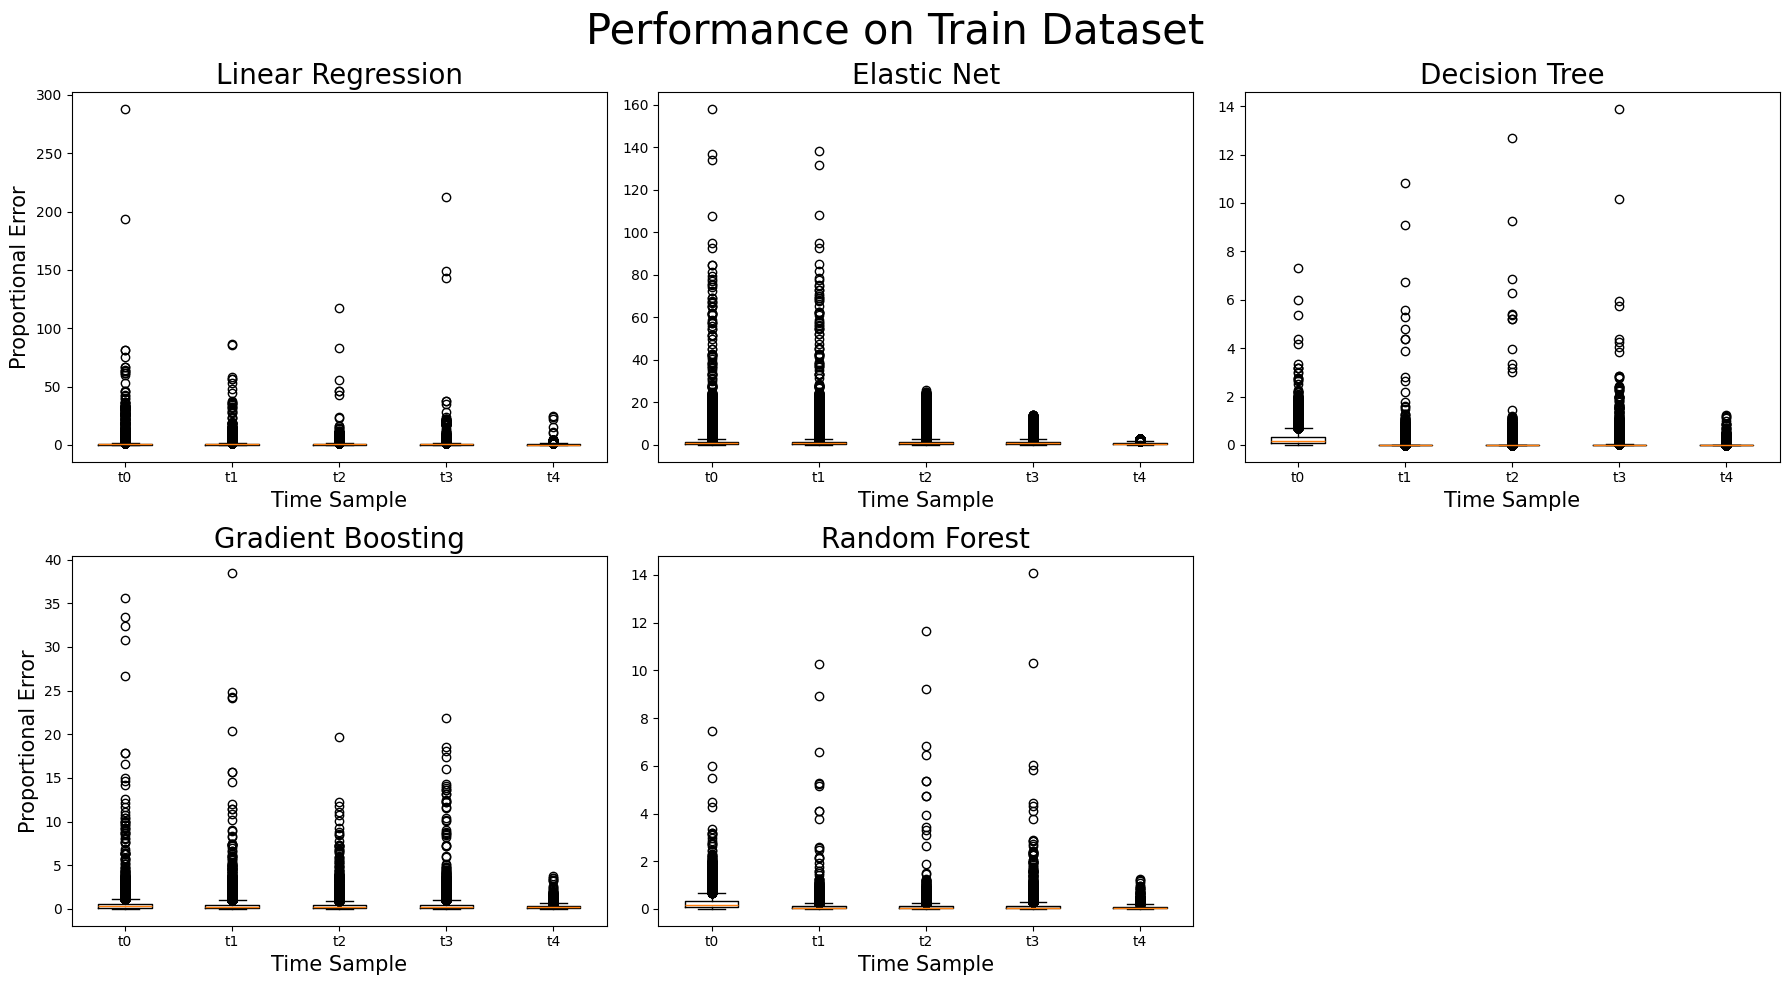

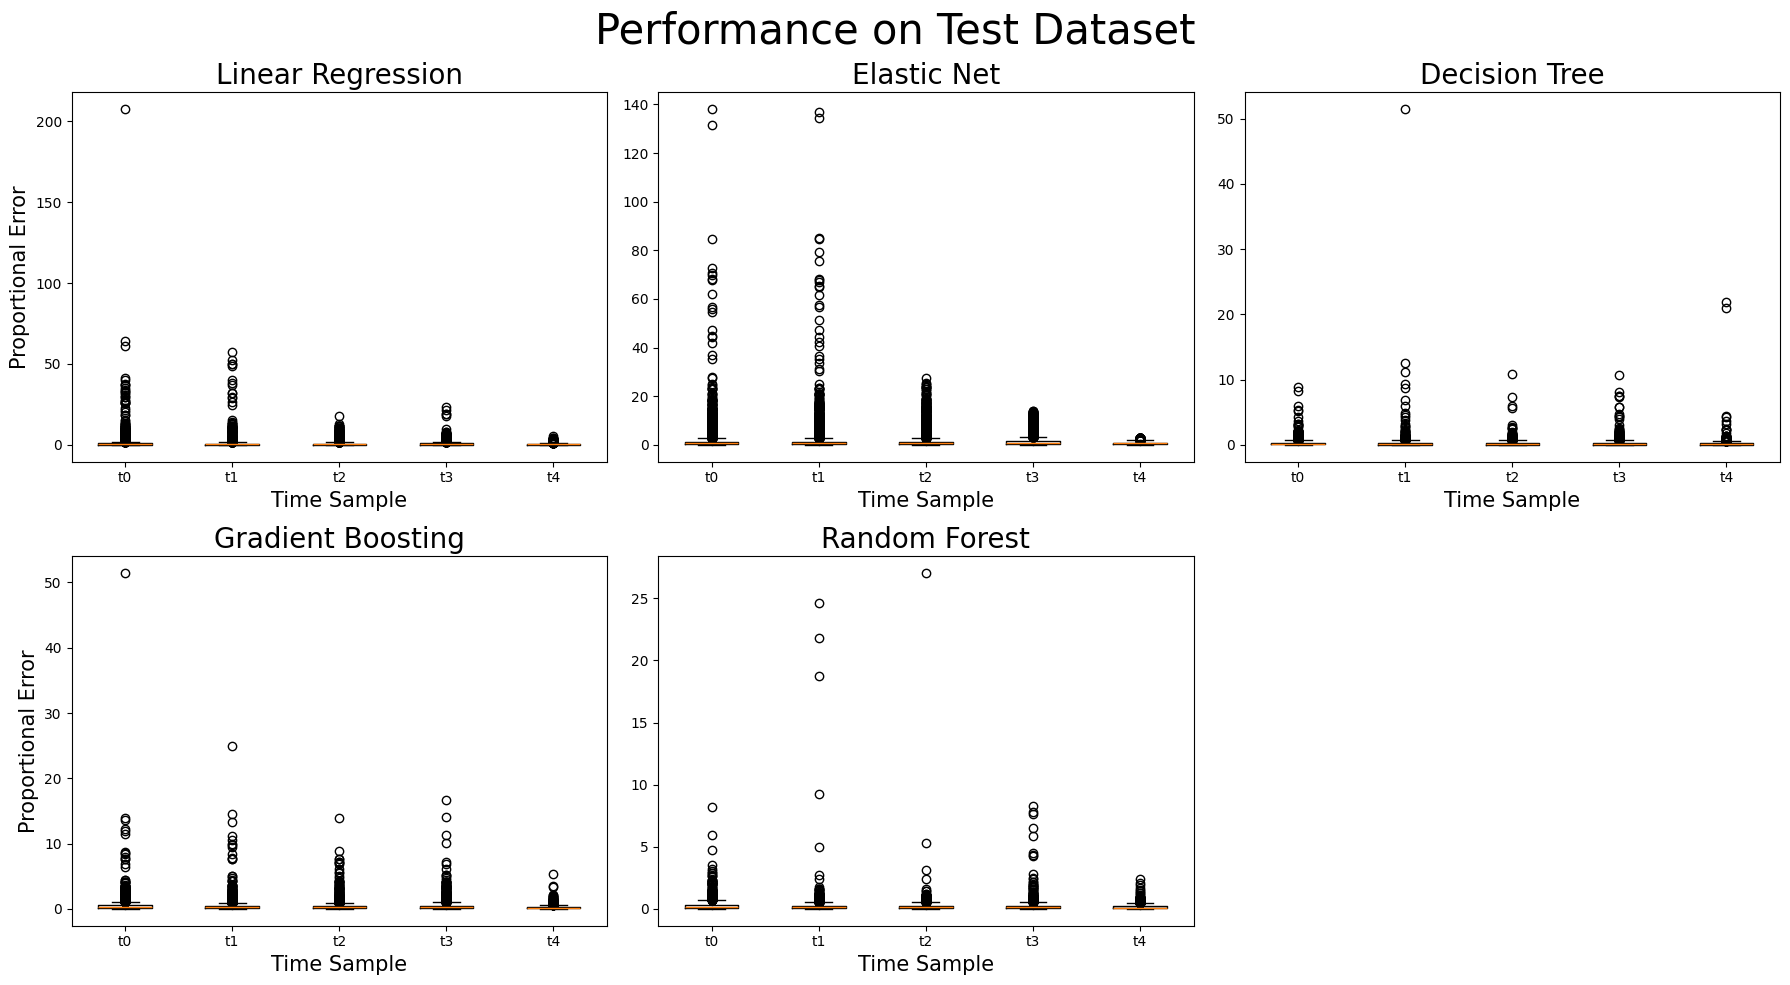

In [11]:
boxplot_prop_errors_by_time(predictions_df)

Looking at the box plots of each of these graphs, there appears to be a few outliers that skew results 